<a href="https://colab.research.google.com/github/IsaacFigNewton/Multiplexed-Hypergraph-Visualizer/blob/main/DAG_to_Hypergraph_to_Power_Diagram.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import and Config

In [1]:
from dag2laguerre import *
import networkx as nx

# Testing PartitionTreeBuilder and RecursivePowerDiagram

In [2]:
sample_dag = nx.DiGraph()
sample_dag.add_edges_from([
    (1, 2),
    (1, 3),
    (2, 4),
    (3, 4),
    (4, 5),
    (4, 8),
    (3, 6),
    (6, 7),
    (5, 8)
])

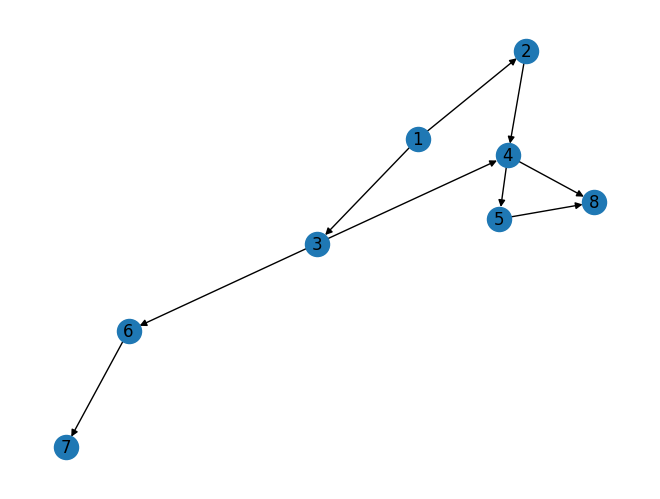

In [3]:
import matplotlib.pyplot as plt

nx.draw(sample_dag, with_labels=True)

In [4]:
partitions = PartitionTreeBuilder(sample_dag).build()

def dict_to_str(d, tabs=0):
  offset = '  '*tabs
  string = ""
  if isinstance(d, dict):
    string += "[\n"
    for k, v in d.items():
      string += f"{offset}{k}: {dict_to_str(v, tabs+1) if len(v) > 0 else None}\n"
    string += f"{offset}]"
    return string
  else:
    return d

print(dict_to_str(partitions))

[
frozenset({1, 2}): None
frozenset({3, 4, 5, 6, 7, 8}): [
  frozenset({8, 4, 5}): [
    frozenset({8, 5}): [
      frozenset({5}): None
      frozenset({8}): None
      ]
    frozenset({4}): None
    ]
  frozenset({3, 6, 7}): [
    frozenset({6}): None
    frozenset({7}): None
    ]
  ]
]


In [5]:
print(partitions)

{frozenset({1, 2}): {}, frozenset({3, 4, 5, 6, 7, 8}): {frozenset({8, 4, 5}): {frozenset({8, 5}): {frozenset({5}): {}, frozenset({8}): {}}, frozenset({4}): {}}, frozenset({3, 6, 7}): {frozenset({6}): {}, frozenset({7}): {}}}}


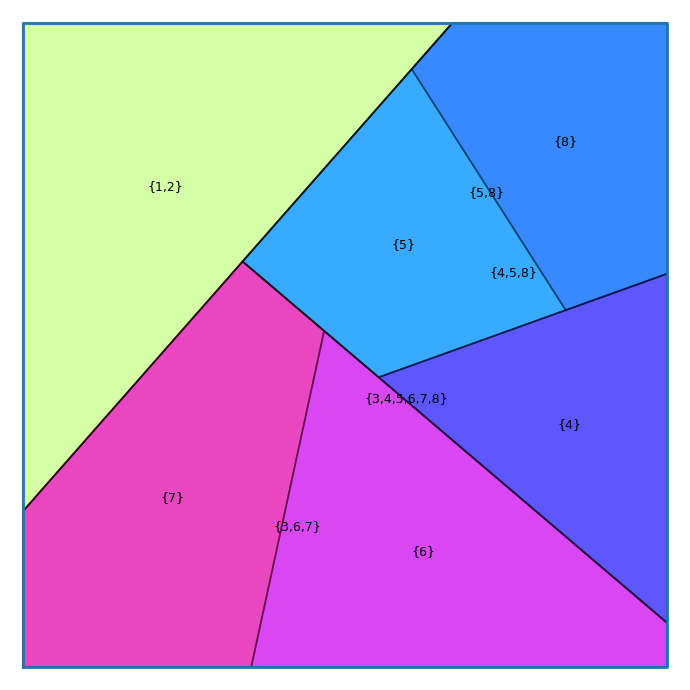

In [6]:
RecursivePowerDiagram(hierarchy=partitions).show()

# Testing pipeline with first few layers of WordNet

In [7]:
"""
Build a WordNet hyponym DAG in a NetworkX DiGraph, limited to the first N layers
starting from the synset 'entity.n.01'.

Requires: nltk, networkx
"""

from collections import deque
import nltk

nltk.download("Wordnet")

from nltk.corpus import wordnet as wn
import networkx as nx


def build_wordnet_hyponym_dag(
    root_synset_name: str = "entity.n.01",
    layers: int = 5,
    ensure_download: bool = True,
) -> nx.DiGraph:
    """
    Downloads WordNet (if requested), then builds a hyponym DAG from `root_synset_name`
    out to `layers` BFS layers (layer 0 = root).

    Nodes are synset names (e.g., "entity.n.01").
    Directed edges go parent -> hyponym.

    Returns:
        nx.DiGraph
    """
    if layers < 0:
        raise ValueError("layers must be >= 0")

    if ensure_download:
        # Download WordNet (and the Open Multilingual WordNet index; harmless if already present).
        nltk.download("wordnet", quiet=True)
        nltk.download("omw-1.4", quiet=True)

    root = wn.synset(root_synset_name)

    G = nx.DiGraph()
    G.add_node(root.name())

    # BFS by synset, tracking depth (layer)
    q = deque([(root, 0)])
    seen = {root.name()}

    while q:
        syn, depth = q.popleft()
        if depth >= layers:
            continue

        for child in syn.hyponyms():
            parent_name = syn.name()
            child_name = child.name()

            G.add_edge(parent_name, child_name)

            if child_name not in seen:
                seen.add(child_name)
                q.append((child, depth + 1))

    return G

[nltk_data] Error loading Wordnet: Package 'Wordnet' not found in
[nltk_data]     index


In [8]:
dag = build_wordnet_hyponym_dag(layers=7)
print(f"Nodes: {dag.number_of_nodes()}, Edges: {dag.number_of_edges()}")
# Example: show a few nodes
print("Sample nodes:", list(dag.nodes())[:10])

Nodes: 35348, Edges: 35826
Sample nodes: ['entity.n.01', 'abstraction.n.06', 'thing.n.08', 'physical_entity.n.01', 'relation.n.01', 'measure.n.02', 'communication.n.02', 'set.n.02', 'attribute.n.02', 'psychological_feature.n.01']


In [9]:
wn_partitions = PartitionTreeBuilder(dag).build()

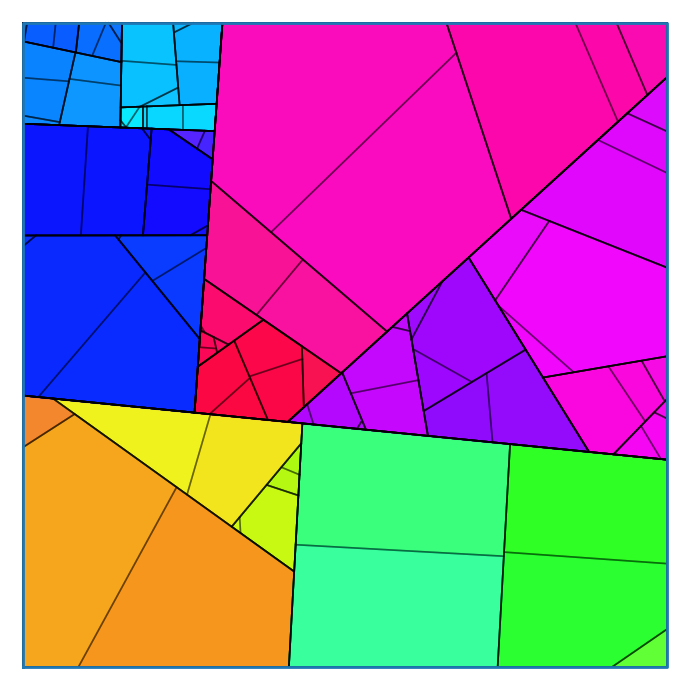

In [10]:
RecursivePowerDiagram(hierarchy=wn_partitions).show(labels=False)